# 02 — Feature Engineering

**Goal:** Convert the validated match sample into numeric features while preserving chronological order and preventing data leakage.

This notebook:

1. applies fixed training, validation, and test boundaries;
2. learns hero and patch vocabularies from training data only;
3. encodes Radiant heroes as `+1` and Dire heroes as `-1`;
4. handles unseen heroes and patches with explicit unknown features; and
5. validates matrix shape, values, sparsity, alignment, and leakage controls.

The result is a consistent feature representation for out-of-time model evaluation.

## Why split before building features?

Defining category vocabularies from the full date range would reveal which heroes and patches appear in later periods. It would not expose the target directly, but it would make the experiment less representative of real use.

The workflow therefore follows this order:

**Chronological split → training-only vocabularies → identical transformation rules for every split.**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

SPLIT_ORDER = ["train", "validation", "test"]
TRAIN_CUTOFF = pd.Timestamp("2022-11-11 00:00:00")
VALIDATION_CUTOFF = pd.Timestamp("2023-11-19 08:14:29")

print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

pandas: 3.0.3
NumPy: 2.5.1


## 1. Load the validated sample

The same path logic used in the EDA notebook supports execution from either the project root or the `notebooks/` directory.

In [2]:
current_directory = Path.cwd().resolve()
root_candidates = [current_directory, current_directory.parent]
project_root = next(
    (candidate for candidate in root_candidates if (candidate / "data" / "processed").exists()),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run from dota2-ml-portfolio/ or notebooks/."
    )

data_path = project_root / "data" / "processed" / "dota2_matches_sample_30000.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Missing sample file: {data_path}")

df = pd.read_csv(data_path, parse_dates=["match_start_date_time"])

print(f"Project root: {project_root}")
print(f"Data file: {data_path.relative_to(project_root)}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Project root: /Users/jeffreyqin/Documents/New project/dota2-ml-portfolio
Data file: data/processed/dota2_matches_sample_30000.csv
Loaded: 30,000 rows x 25 columns


## 2. Apply the chronological split

The boundaries come from the EDA. Matches exactly on a cutoff remain in the earlier period so a timestamp is never shared across two splits.

- Training: through 2022-11-11
- Validation: after 2022-11-11 through 2023-11-19 08:14:29
- Test: after 2023-11-19 08:14:29

In [3]:
df["split"] = np.select(
    [
        df["match_start_date_time"] <= TRAIN_CUTOFF,
        df["match_start_date_time"] <= VALIDATION_CUTOFF,
    ],
    ["train", "validation"],
    default="test",
)

split_summary = (
    df.groupby("split", as_index=False)
    .agg(
        matches=("match_id", "size"),
        first_match=("match_start_date_time", "min"),
        last_match=("match_start_date_time", "max"),
        radiant_win_rate=("radiant_win", "mean"),
    )
)
split_summary["split"] = pd.Categorical(
    split_summary["split"], categories=SPLIT_ORDER, ordered=True
)
split_summary = split_summary.sort_values("split")
split_summary["share"] = split_summary["matches"] / len(df)
display(split_summary)

print(f"Training cutoff: {TRAIN_CUTOFF}")
print(f"Validation cutoff: {VALIDATION_CUTOFF}")

,split,matches,first_match,last_match,radiant_win_rate,share
1,train,21004,2011-08-17 00:00:00,2022-11-11 00:00:00,0.5135,0.7001
2,validation,4496,2022-11-12 00:00:00,2023-11-19 08:14:29,0.5016,0.1499
0,test,4500,2023-11-19 08:38:55,2024-10-15 01:28:24,0.5098,0.1500


Training cutoff: 2022-11-11 00:00:00
Validation cutoff: 2023-11-19 08:14:29


In [4]:
split_checks = pd.DataFrame(
    [
        ("All rows assigned", df["split"].notna().all()),
        ("Expected split labels", set(df["split"].unique()) == set(SPLIT_ORDER)),
        (
            "Training ends before validation",
            df.loc[df["split"] == "train", "match_start_date_time"].max()
            < df.loc[df["split"] == "validation", "match_start_date_time"].min(),
        ),
        (
            "Validation ends before test",
            df.loc[df["split"] == "validation", "match_start_date_time"].max()
            < df.loc[df["split"] == "test", "match_start_date_time"].min(),
        ),
    ],
    columns=["check", "passed"],
)
split_checks["status"] = np.where(split_checks["passed"], "PASS", "REVIEW")
display(split_checks.drop(columns="passed"))
assert split_checks["passed"].all(), "At least one chronological split check failed."

,check,status
0,All rows assigned,PASS
1,Expected split labels,PASS
2,Training ends before validation,PASS
3,Validation ends before test,PASS


**Feature rule:** `split` is an experiment-management field, not a model input. The model must not receive information about which evaluation period contains a match.

## 3. Separate metadata, target, and inputs

- `match_id`, match time, and `split` support tracing and evaluation.
- `radiant_win` is the target.
- Hero and patch names are display labels.
- Numeric features are reconstructed from hero IDs and patch IDs.

Keeping these groups separate reduces the risk of identifiers or the target entering the feature matrix.

In [5]:
hero_id_columns = [
    f"{side}_player_{slot}_hero_id"
    for side in ("radiant", "dire")
    for slot in range(1, 6)
]
hero_name_columns = [column.removesuffix("_id") for column in hero_id_columns]

row_metadata = df[["match_id", "match_start_date_time", "split"]].copy()
target = df["radiant_win"].astype("int8").rename("radiant_win")

role_summary = pd.DataFrame(
    [
        ("Tracking", "match_id, match_start_date_time, split", "Not features"),
        ("Target", "radiant_win", "Label only"),
        ("Hero inputs", "10 hero ID columns", "Side-aware encoding"),
        ("Patch input", "game_version_id", "Train-vocabulary one-hot encoding"),
        ("Display only", "hero names, game_version", "Not features"),
    ],
    columns=["role", "columns", "handling"],
)
display(role_summary)

,role,columns,handling
0,Tracking,"match_id, match_start_date_time, split",Not features
1,Target,radiant_win,Label only
2,Hero inputs,10 hero ID columns,Side-aware encoding
3,Patch input,game_version_id,Train-vocabulary one-hot encoding
4,Display only,"hero names, game_version",Not features


## 4. Learn vocabularies from training data

The vocabularies determine the feature columns. Validation and test data cannot add columns because categories observed later would not have been available when the model was fitted.

In [6]:
train_mask = df["split"].eq("train")

train_hero_ids = sorted(
    pd.unique(df.loc[train_mask, hero_id_columns].to_numpy().ravel()).tolist()
)
train_patch_ids = sorted(df.loc[train_mask, "game_version_id"].unique().tolist())

print(f"Training hero vocabulary: {len(train_hero_ids)} heroes")
print(f"Training patch vocabulary: {len(train_patch_ids)} patches")
print(f"Hero ID range: {min(train_hero_ids)} to {max(train_hero_ids)}")

Training hero vocabulary: 123 heroes
Training patch vocabulary: 136 patches
Hero ID range: 1 to 137


### Identify unseen categories

New heroes and patches are expected in later Dota 2 data. They are measured here and mapped to explicit unknown features instead of being added to the training vocabulary.

In [7]:
pick_frames = []
for side in ("radiant", "dire"):
    for slot in range(1, 6):
        id_column = f"{side}_player_{slot}_hero_id"
        name_column = f"{side}_player_{slot}_hero"
        frame = df[["match_id", "split", id_column, name_column]].rename(
            columns={id_column: "hero_id", name_column: "hero_name"}
        )
        frame["side"] = side
        pick_frames.append(frame)

all_picks = pd.concat(pick_frames, ignore_index=True)
unseen_picks = all_picks[~all_picks["hero_id"].isin(train_hero_ids)].copy()

unseen_hero_summary = (
    unseen_picks.groupby("split")
    .agg(
        unseen_picks=("hero_id", "size"),
        unseen_hero_ids=("hero_id", "nunique"),
        affected_matches=("match_id", "nunique"),
    )
    .reindex(SPLIT_ORDER, fill_value=0)
    .reset_index()
)
display(unseen_hero_summary)

unseen_hero_catalog = (
    unseen_picks.groupby(["hero_id", "hero_name"], as_index=False)
    .agg(
        first_seen_split=("split", "first"),
        picks=("match_id", "size"),
        first_match_id=("match_id", "min"),
    )
    .sort_values(["first_seen_split", "hero_id"])
)
display(unseen_hero_catalog)

,split,unseen_picks,unseen_hero_ids,affected_matches
0,train,0,0,0
1,validation,293,1,293
2,test,227,1,227


,hero_id,hero_name,first_seen_split,picks,first_match_id
0,138,Muerta,validation,520,7116836149


In [8]:
unseen_patch_rows = df[~df["game_version_id"].isin(train_patch_ids)].copy()
unseen_patch_summary = (
    unseen_patch_rows.groupby("split")
    .agg(
        matches_with_unseen_patch=("match_id", "size"),
        unseen_patch_ids=("game_version_id", "nunique"),
    )
    .reindex(SPLIT_ORDER, fill_value=0)
    .reset_index()
)
display(unseen_patch_summary)

unseen_patch_catalog = (
    unseen_patch_rows[["split", "game_version_id", "game_version"]]
    .drop_duplicates()
    .sort_values(["split", "game_version_id"])
)
display(unseen_patch_catalog.head(20))

,split,matches_with_unseen_patch,unseen_patch_ids
0,train,0,0
1,validation,4351,11
2,test,4500,10


,split,game_version_id,game_version
25500,test,167,7.34d
25681,test,168,7.34e
25769,test,169,7.35
25871,test,170,7.35b
26778,test,171,7.35c
27303,test,172,7.35d
28010,test,173,7.36
28535,test,175,7.36c
28912,test,176,7.37
29841,test,177,7.37d


**Result and decision:** Muerta is the only hero absent from the training vocabulary, and most later matches use unseen patches. Side-specific unknown hero counts preserve which team selected an unseen hero, while `patch_unknown` keeps the matrix structure fixed. The model cannot learn category-specific weights for values it has never observed.

## 5. Encode heroes with side information

Each hero observed during training receives one feature column:

- Radiant pick: `+1`
- Dire pick: `-1`
- Not picked: `0`

A hero cannot appear on both teams in the same match, so a column cannot contain both signs within one row. This representation preserves side information without treating hero IDs as continuous numbers.

In [9]:
def build_hero_features(frame, hero_vocabulary):
    vocabulary = pd.Index(hero_vocabulary, dtype="int64")
    matrix = np.zeros((len(frame), len(vocabulary)), dtype=np.int8)
    row_positions = np.arange(len(frame))
    unknown_counts = {
        "unknown_radiant_hero_count": np.zeros(len(frame), dtype=np.int8),
        "unknown_dire_hero_count": np.zeros(len(frame), dtype=np.int8),
    }

    for side, value in (("radiant", 1), ("dire", -1)):
        unknown_column = f"unknown_{side}_hero_count"
        for slot in range(1, 6):
            source_column = f"{side}_player_{slot}_hero_id"
            hero_values = frame[source_column].to_numpy(dtype="int64")
            vocabulary_positions = vocabulary.get_indexer(hero_values)
            known_mask = vocabulary_positions >= 0

            matrix[
                row_positions[known_mask], vocabulary_positions[known_mask]
            ] = value
            unknown_counts[unknown_column] += (~known_mask).astype(np.int8)

    hero_features = pd.DataFrame(
        matrix,
        index=frame.index,
        columns=[f"hero_{hero_id}" for hero_id in vocabulary],
    )
    unknown_features = pd.DataFrame(unknown_counts, index=frame.index)
    return hero_features, unknown_features


hero_features, unknown_hero_features = build_hero_features(df, train_hero_ids)

print(f"Hero feature matrix: {hero_features.shape}")
display(unknown_hero_features.groupby(df["split"]).sum().reindex(SPLIT_ORDER))

Hero feature matrix: (30000, 123)


,unknown_radiant_hero_count,unknown_dire_hero_count
split,,
train,0,0
validation,156,137
test,112,115


### Interpret the encoding for one match

The chart shows only the ten heroes selected in one training match. Positive bars represent Radiant picks and negative bars represent Dire picks. All unselected hero columns are zero.

,side,slot,hero_id,hero_name,encoded_value
0,Radiant,1,18,Sven,1
1,Radiant,2,25,Lina,1
2,Radiant,3,69,Doom,1
3,Radiant,4,53,Nature's Prophet,1
4,Radiant,5,17,Storm Spirit,1
5,Dire,1,33,Enigma,-1
6,Dire,2,5,Crystal Maiden,-1
7,Dire,3,1,Anti-Mage,-1
8,Dire,4,16,Sand King,-1
9,Dire,5,11,Shadow Fiend,-1


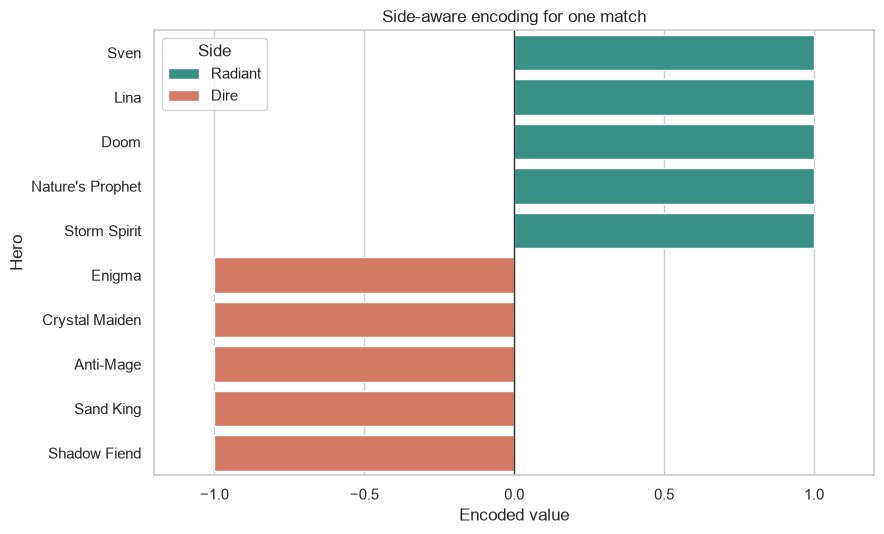

In [10]:
example_index = df.index[df["split"].eq("train")][0]
example_records = []

for side, value in (("Radiant", 1), ("Dire", -1)):
    side_key = side.lower()
    for slot in range(1, 6):
        example_records.append(
            {
                "side": side,
                "slot": slot,
                "hero_id": int(df.loc[example_index, f"{side_key}_player_{slot}_hero_id"]),
                "hero_name": df.loc[example_index, f"{side_key}_player_{slot}_hero"],
                "encoded_value": value,
            }
        )

example_encoding = pd.DataFrame(example_records)
display(example_encoding)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=example_encoding,
    x="encoded_value",
    y="hero_name",
    hue="side",
    palette={"Radiant": "#2A9D8F", "Dire": "#E76F51"},
    ax=ax,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_xlim(-1.2, 1.2)
ax.set_title("Side-aware encoding for one match")
ax.set_xlabel("Encoded value")
ax.set_ylabel("Hero")
ax.legend(title="Side")
plt.tight_layout()
plt.show()

## 6. One-hot encode patches

Each patch observed during training receives one binary column. A patch first seen in validation or test activates `patch_unknown`, which keeps the training, validation, and test matrices structurally identical.

In [11]:
def build_patch_features(frame, patch_vocabulary):
    known_patch_mask = frame["game_version_id"].isin(patch_vocabulary)
    known_patch_values = frame["game_version_id"].where(known_patch_mask)
    categorical = pd.Categorical(
        known_patch_values, categories=patch_vocabulary
    )
    patch_features = pd.get_dummies(
        categorical, prefix="patch", dtype=np.int8
    )
    patch_features.index = frame.index
    patch_features["patch_unknown"] = (~known_patch_mask).astype(np.int8)
    return patch_features


patch_features = build_patch_features(df, train_patch_ids)

print(f"Patch feature matrix: {patch_features.shape}")
display(
    patch_features.groupby(df["split"])["patch_unknown"]
    .sum()
    .reindex(SPLIT_ORDER)
    .rename("matches_with_unknown_patch")
    .to_frame()
)

Patch feature matrix: (30000, 137)


,matches_with_unknown_patch
split,
train,0
validation,4351
test,4500


## 7. Assemble the feature matrix

The final matrix combines known hero columns, two side-specific unknown hero counts, known patch columns, and one unknown-patch flag.

`row_metadata` and `target` remain separate so tracking fields and the label cannot enter the model inputs accidentally.

In [12]:
feature_matrix = pd.concat(
    [hero_features, unknown_hero_features, patch_features], axis=1
).astype(np.int8)

feature_family_summary = pd.DataFrame(
    [
        ("Known hero columns", hero_features.shape[1]),
        ("Unknown hero count columns", unknown_hero_features.shape[1]),
        ("Known patch columns", patch_features.shape[1] - 1),
        ("Unknown patch flag", 1),
    ],
    columns=["feature_family", "columns"],
)

print(f"Final feature matrix: {feature_matrix.shape}")
print(f"Target vector: {target.shape}")
display(feature_family_summary)
display(feature_matrix.iloc[:3, :12])

Final feature matrix: (30000, 262)
Target vector: (30000,)


,feature_family,columns
0,Known hero columns,123
1,Unknown hero count columns,2
2,Known patch columns,136
3,Unknown patch flag,1


,hero_1,hero_2,hero_3,hero_4,hero_5,hero_6,hero_7,hero_8,hero_9,hero_10,hero_11,hero_12
0,-1,0,0,0,-1,0,0,0,0,0,-1,0
1,1,0,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0


In [13]:
feature_sets = {
    split_name: feature_matrix.loc[df["split"].eq(split_name)].copy()
    for split_name in SPLIT_ORDER
}
target_sets = {
    split_name: target.loc[df["split"].eq(split_name)].copy()
    for split_name in SPLIT_ORDER
}
metadata_sets = {
    split_name: row_metadata.loc[df["split"].eq(split_name)].copy()
    for split_name in SPLIT_ORDER
}

matrix_split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": feature_sets[split_name].shape[0],
            "feature_columns": feature_sets[split_name].shape[1],
            "target_rows": len(target_sets[split_name]),
            "radiant_win_rate": target_sets[split_name].mean(),
        }
        for split_name in SPLIT_ORDER
    ]
)
display(matrix_split_summary)

,split,rows,feature_columns,target_rows,radiant_win_rate
0,train,21004,262,21004,0.5135
1,validation,4496,262,4496,0.5016
2,test,4500,262,4500,0.5098


## 8. Validate feature quality and leakage controls

These assertions act as feature-level tests. They check missing values, duplicate columns, valid encodings, ten accounted hero picks, one active patch feature, aligned indexes, consistent split columns, and the absence of forbidden fields.

In [14]:
hero_values = set(np.unique(hero_features.to_numpy()).tolist())
known_hero_counts = hero_features.ne(0).sum(axis=1)
unknown_hero_counts = unknown_hero_features.sum(axis=1)
patch_active_counts = patch_features.sum(axis=1)

forbidden_feature_names = {
    "match_id",
    "match_start_date_time",
    "split",
    "radiant_win",
    "winner_id",
    "match_duration_seconds",
    "first_blood_time_seconds",
    "radiant_kills",
    "dire_kills",
}

feature_checks = pd.DataFrame(
    [
        ("No missing feature values", not feature_matrix.isna().any().any()),
        ("No duplicate feature columns", not feature_matrix.columns.duplicated().any()),
        ("Hero values are -1, 0, or 1", hero_values.issubset({-1, 0, 1})),
        (
            "Every row accounts for 10 hero picks",
            (known_hero_counts + unknown_hero_counts).eq(10).all(),
        ),
        ("Exactly one patch feature per row", patch_active_counts.eq(1).all()),
        (
            "No forbidden fields in feature matrix",
            forbidden_feature_names.isdisjoint(feature_matrix.columns),
        ),
        ("Feature and target indexes align", feature_matrix.index.equals(target.index)),
        (
            "All splits share identical feature columns",
            all(
                feature_sets[split_name].columns.equals(feature_matrix.columns)
                for split_name in SPLIT_ORDER
            ),
        ),
        (
            "Split row counts match targets",
            all(
                len(feature_sets[split_name]) == len(target_sets[split_name])
                for split_name in SPLIT_ORDER
            ),
        ),
    ],
    columns=["check", "passed"],
)
feature_checks["status"] = np.where(feature_checks["passed"], "PASS", "REVIEW")
display(feature_checks.drop(columns="passed"))

assert feature_checks["passed"].all(), "At least one feature-quality check failed."
print("All feature-quality and leakage checks passed.")

,check,status
0,No missing feature values,PASS
1,No duplicate feature columns,PASS
2,"Hero values are -1, 0, or 1",PASS
3,Every row accounts for 10 hero picks,PASS
4,Exactly one patch feature per row,PASS
5,No forbidden fields in feature matrix,PASS
6,Feature and target indexes align,PASS
7,All splits share identical feature columns,PASS
8,Split row counts match targets,PASS


All feature-quality and leakage checks passed.


## 9. Measure sparsity and memory use

Most values in one-hot-style features are zero. The matrix remains an `int8` pandas DataFrame here for easy inspection; the modeling notebook converts it to a sparse matrix for efficient training.

In [15]:
nonzero_features_per_row = feature_matrix.ne(0).sum(axis=1)
nonzero_values = int(feature_matrix.ne(0).sum().sum())
total_values = int(feature_matrix.shape[0] * feature_matrix.shape[1])
density = nonzero_values / total_values
memory_mb = feature_matrix.memory_usage(deep=True).sum() / 1024**2

sparsity_summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "feature_columns",
            "nonzero_values",
            "total_values",
            "density",
            "memory_mb",
        ],
        "value": [
            feature_matrix.shape[0],
            feature_matrix.shape[1],
            nonzero_values,
            total_values,
            density,
            memory_mb,
        ],
    }
)
display(sparsity_summary)

active_feature_distribution = (
    nonzero_features_per_row.value_counts()
    .sort_index()
    .rename_axis("nonzero_feature_columns")
    .rename("matches")
    .reset_index()
)
active_feature_distribution["share"] = (
    active_feature_distribution["matches"] / len(feature_matrix)
)
display(active_feature_distribution)

,metric,value
0,rows,"30,000.0000"
1,feature_columns,262.0000
2,nonzero_values,"330,000.0000"
3,total_values,"7,860,000.0000"
4,density,0.0420
5,memory_mb,7.4960


,nonzero_feature_columns,matches,share
0,11,30000,1.0000


## 10. Document the feature contract

The manifest records each feature family, its source, allowed values, and handling of categories first observed after training. It defines the input structure expected by the baseline model.

In [16]:
feature_manifest = pd.DataFrame(
    [
        (
            "Known heroes",
            hero_features.shape[1],
            "Training hero IDs",
            "-1, 0, 1",
            "One column per training hero",
        ),
        (
            "Unknown Radiant heroes",
            1,
            "Future Radiant picks",
            "0 to 5",
            "Count in unknown_radiant_hero_count",
        ),
        (
            "Unknown Dire heroes",
            1,
            "Future Dire picks",
            "0 to 5",
            "Count in unknown_dire_hero_count",
        ),
        (
            "Known patches",
            patch_features.shape[1] - 1,
            "Training patch IDs",
            "0 or 1",
            "One-hot columns",
        ),
        (
            "Unknown patch",
            1,
            "Future patch IDs",
            "0 or 1",
            "Single patch_unknown flag",
        ),
    ],
    columns=["feature_family", "columns", "source", "values", "handling"],
)
display(feature_manifest)

,feature_family,columns,source,values,handling
0,Known heroes,123,Training hero IDs,"-1, 0, 1",One column per training hero
1,Unknown Radiant heroes,1,Future Radiant picks,0 to 5,Count in unknown_radiant_hero_count
2,Unknown Dire heroes,1,Future Dire picks,0 to 5,Count in unknown_dire_hero_count
3,Known patches,136,Training patch IDs,0 or 1,One-hot columns
4,Unknown patch,1,Future patch IDs,0 or 1,Single patch_unknown flag


## 11. Feature-engineering summary

The following summary reports split sizes, feature dimensions, sparsity, and unseen-category handling.

In [17]:
unseen_hero_pick_count = int(len(unseen_picks))
unseen_patch_match_count = int(len(unseen_patch_rows))

summary_text = f'''
### Main feature-engineering findings

- Chronological rows: **{len(feature_sets['train']):,} train**, **{len(feature_sets['validation']):,} validation**, and **{len(feature_sets['test']):,} test**.
- The training vocabulary contains **{len(train_hero_ids)} heroes** and **{len(train_patch_ids)} patches**.
- Later-period data contains **{unseen_hero_pick_count:,} unseen hero picks** and **{unseen_patch_match_count:,} matches on unseen patches**.
- The final in-memory matrix has **{feature_matrix.shape[0]:,} rows x {feature_matrix.shape[1]} feature columns**.
- Matrix density is **{density:.2%}**, using about **{memory_mb:.2f} MB** as an int8 pandas DataFrame.
- All split, feature-accounting, index-alignment, and leakage checks passed.
- The validated matrix is ready for sparse conversion and baseline modeling.
'''
display(Markdown(summary_text))


### Main feature-engineering findings

- Chronological rows: **21,004 train**, **4,496 validation**, and **4,500 test**.
- The training vocabulary contains **123 heroes** and **136 patches**.
- Later-period data contains **520 unseen hero picks** and **8,851 matches on unseen patches**.
- The final in-memory matrix has **30,000 rows x 262 feature columns**.
- Matrix density is **4.20%**, using about **7.50 MB** as an int8 pandas DataFrame.
- All split, feature-accounting, index-alignment, and leakage checks passed.
- The validated matrix is ready for sparse conversion and baseline modeling.


## Feature-engineering decision

The validated representation contains 262 columns with identical structure across all three time periods. Hero side is encoded explicitly, later categories use fixed unknown features, and all tracking, target, and post-match fields remain excluded.

This matrix is suitable for a sparse linear baseline. Model selection will use validation data, with the test period reserved for one final out-of-time evaluation.